In [1]:
# This code is part of QCMet.
# 
# (C) Copyright 2024 National Physical Laboratory and National Quantum Computing Centre 
# 
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
# 
#      http://www.apache.org/licenses/LICENSE-2.0
# 
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License

# Accreditation protocol

Accreditation Protocol (AP) is a protocol devised to characterize the reliability of noisy quantum devices. AP provides an upper bound, denoted as b, on the variation distance (VD).

Given a noisy quantum device implementing a "target" quantum circuit, AP certifies an upper-bound on the variation distance between the probability distribution of the outputs returned by the device and the ideal probability distribution.
This method is based on Samuele Ferracin *et al*. Accrediting outputs of noisy intermediate-scale quantum devices. New J. Phys. **21** 113038 (2019).

This notebook gives an example showing how to accredit the outputs of a 4-qubit quantum circuit. You can change the target circuit to accredit other circuits.

In [26]:
import numpy as np
import warnings
warnings.filterwarnings('ignore')
from qiskit_aer import AerSimulator
from qiskit import QuantumCircuit

## Function to generate random trap circuits based on a given target circuit

In [27]:
def generate_trap_circuits(num_traps, target_circuit: QuantumCircuit):
    circuit_data = target_circuit.data
    depth_tracker = [0 for _ in range(target_circuit.num_qubits)]
    layer_indices_of_gates = []
    gate_types = []
    for gate in circuit_data:
        if gate.operation.name in ["measure", "barrier"]:
            continue
        num_qubits = gate.operation.num_qubits
        if num_qubits not in [1, 2]:
            raise ValueError(f"The target circuit can only have one or two qubit gates. Wrong gate: {gate}")
        gate_types.append(num_qubits)
        
        if num_qubits == 1:
            layer_indices_of_gates.append(depth_tracker[gate.qubits[0].index])
        else:
            qubit_index0 = gate.qubits[0].index
            qubit_index1 = gate.qubits[1].index
            max_depth = max(depth_tracker[qubit_index0], depth_tracker[qubit_index1])
            layer_indices_of_gates.append(max_depth)
            depth_tracker[qubit_index0] = max_depth + 1
            depth_tracker[qubit_index1] = max_depth + 1
    # print(depth_tracker)
    # for gate, layer_index in zip(circuit_data, layer_indices_of_gates):
    #     print(gate.operation.name, layer_index)
    
    target_circuit_gate_existence_in_layers = [{1: [False for _ in range(target_circuit.num_qubits)], 2: []} for _ in range(max(layer_indices_of_gates) + 1)]
    for gate, layer_index in zip(circuit_data, layer_indices_of_gates):
        if gate.operation.num_qubits == 1:
            target_circuit_gate_existence_in_layers[layer_index][gate.operation.num_qubits][gate.qubits[0].index] = True
        else:
            target_circuit_gate_existence_in_layers[layer_index][gate.operation.num_qubits].append([gate.qubits[0].index, gate.qubits[1].index, gate])
     
    # Generate random trap circuits
    trap_circuits = []
    for _ in range(num_traps):
        trap_circuit = QuantumCircuit(target_circuit.num_qubits)
        
        # Randomly decide if we add additional H gates at the beginning and end
        add_additional_h_gates = False
        if np.random.rand() < 0.5:
            for i in range(target_circuit.num_qubits):
                trap_circuit.h(i)
                add_additional_h_gates = True
        
        for gate_existence_of_each_layer in target_circuit_gate_existence_in_layers:  # For each layer
            undo_gates = []
            for qubit_index, oneq_exist in enumerate(gate_existence_of_each_layer[1]):  # For each single qubit gate in each layer
                oneq_exist_in_twoq = False
                for twoq_indices in gate_existence_of_each_layer[2][:2]:
                    oneq_exist_in_twoq = oneq_exist_in_twoq or qubit_index in twoq_indices
                if oneq_exist and not oneq_exist_in_twoq:  # There is 1q gate on this qubit but no 2q gate
                    # Randomly replace the 1q gate with H or S
                    if np.random.rand() < 0.5:
                        trap_circuit.h(qubit_index)
                        undo_gates.append([qubit_index, "h"])
                    else:
                        trap_circuit.s(qubit_index)
                        undo_gates.append([qubit_index, "s"])
                        
            for qubit_index0, qubit_index1, gate in gate_existence_of_each_layer[2]:  # For each 2q gate, we'll add/replace 1q gates
                # Randomly replace the 1q gates (or add if there isn't already a 1q gate) with [H and S] or [S and H]
                if np.random.rand() < 0.5:
                    trap_circuit.h(qubit_index0)
                    trap_circuit.s(qubit_index1)
                    trap_circuit.append(gate)
                    undo_gates.append([qubit_index0, "h"])
                    undo_gates.append([qubit_index1, "s"])
                else:
                    trap_circuit.s(qubit_index0)
                    trap_circuit.h(qubit_index1)
                    trap_circuit.append(gate)
                    undo_gates.append([qubit_index0, "s"])
                    undo_gates.append([qubit_index1, "h"])
            
            # Add the so-called undo gates
            for undo_index, undo_gate in undo_gates:
                if undo_gate == "h":
                    trap_circuit.h(undo_index)
                else:
                    trap_circuit.sdg(undo_index)
            # Add barrier in between layers
            trap_circuit.barrier()
            
        # Add ending H gates
        if add_additional_h_gates:
            for i in range(target_circuit.num_qubits):
                trap_circuit.h(i)
        
        trap_circuit.measure_all()
        
        trap_circuits.append(trap_circuit)
    
    return trap_circuits
                

## Construct the target circuit

Note that the target circuit must satisfy the following restrictions:

 - it takes as input $N_{\mathrm{q}}$ qubits in the state $\ket{0}^{\otimes N_{\mathrm{q}}}$,
 - it contains $2m$ cycles alternating between a cycle of one-qubit gates and a cycle of two-qubit gates, which can be efficiently chosen to be $\mathrm{C}_Z$ or another two-qubit Clifford gate,
 - it ends with measurements in the Pauli-$Z$ basis.

We will create the target circuit to contain multiple repetitions of the same structure, so that the noisy simulation results will differ from the noiseless simulation results by a large amount.

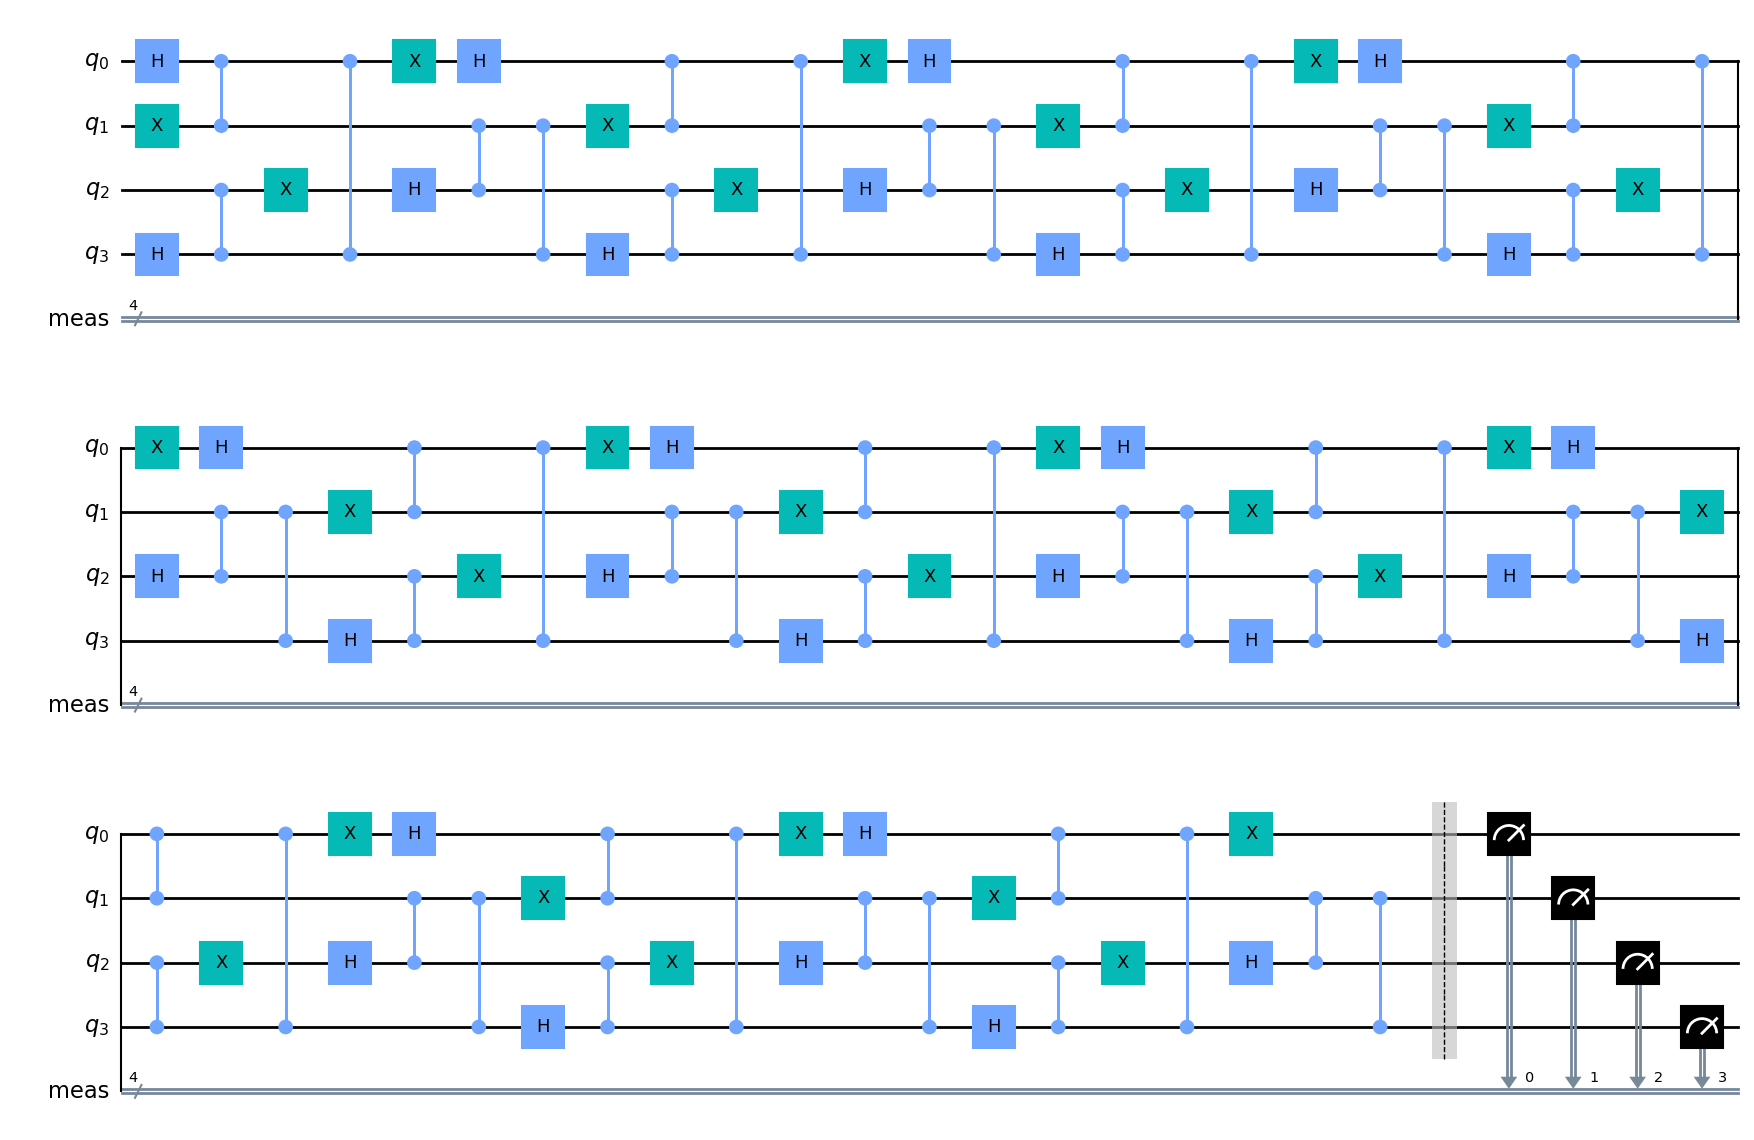

In [28]:
tc = QuantumCircuit(4)
for _ in range(10):  # Repeat the following for many times
    tc.h(0)
    tc.x(1)
    tc.h(3)
    tc.cz(0, 1)
    tc.cz(2, 3)
    tc.x(2)
    tc.h(2)
    tc.cz(1, 2)
    tc.cz(0, 3)
    tc.x(0)
    tc.cz(1, 3)

tc.measure_all()
tc.draw(output='mpl')


## Generate trap circuits

In [29]:
mu = 0.0001  # Desired accuracy (0, 1)
eta = 0.9999  # Desired confidence (0, 1)
v = int(np.ceil(2 * np.log((2 / (1 - eta)) / mu ** 2)))  # Number of trap circuits to generate
print(f'{v} trap circuits generated')

57 trap circuits generated


An example trap circuit looks like the following:

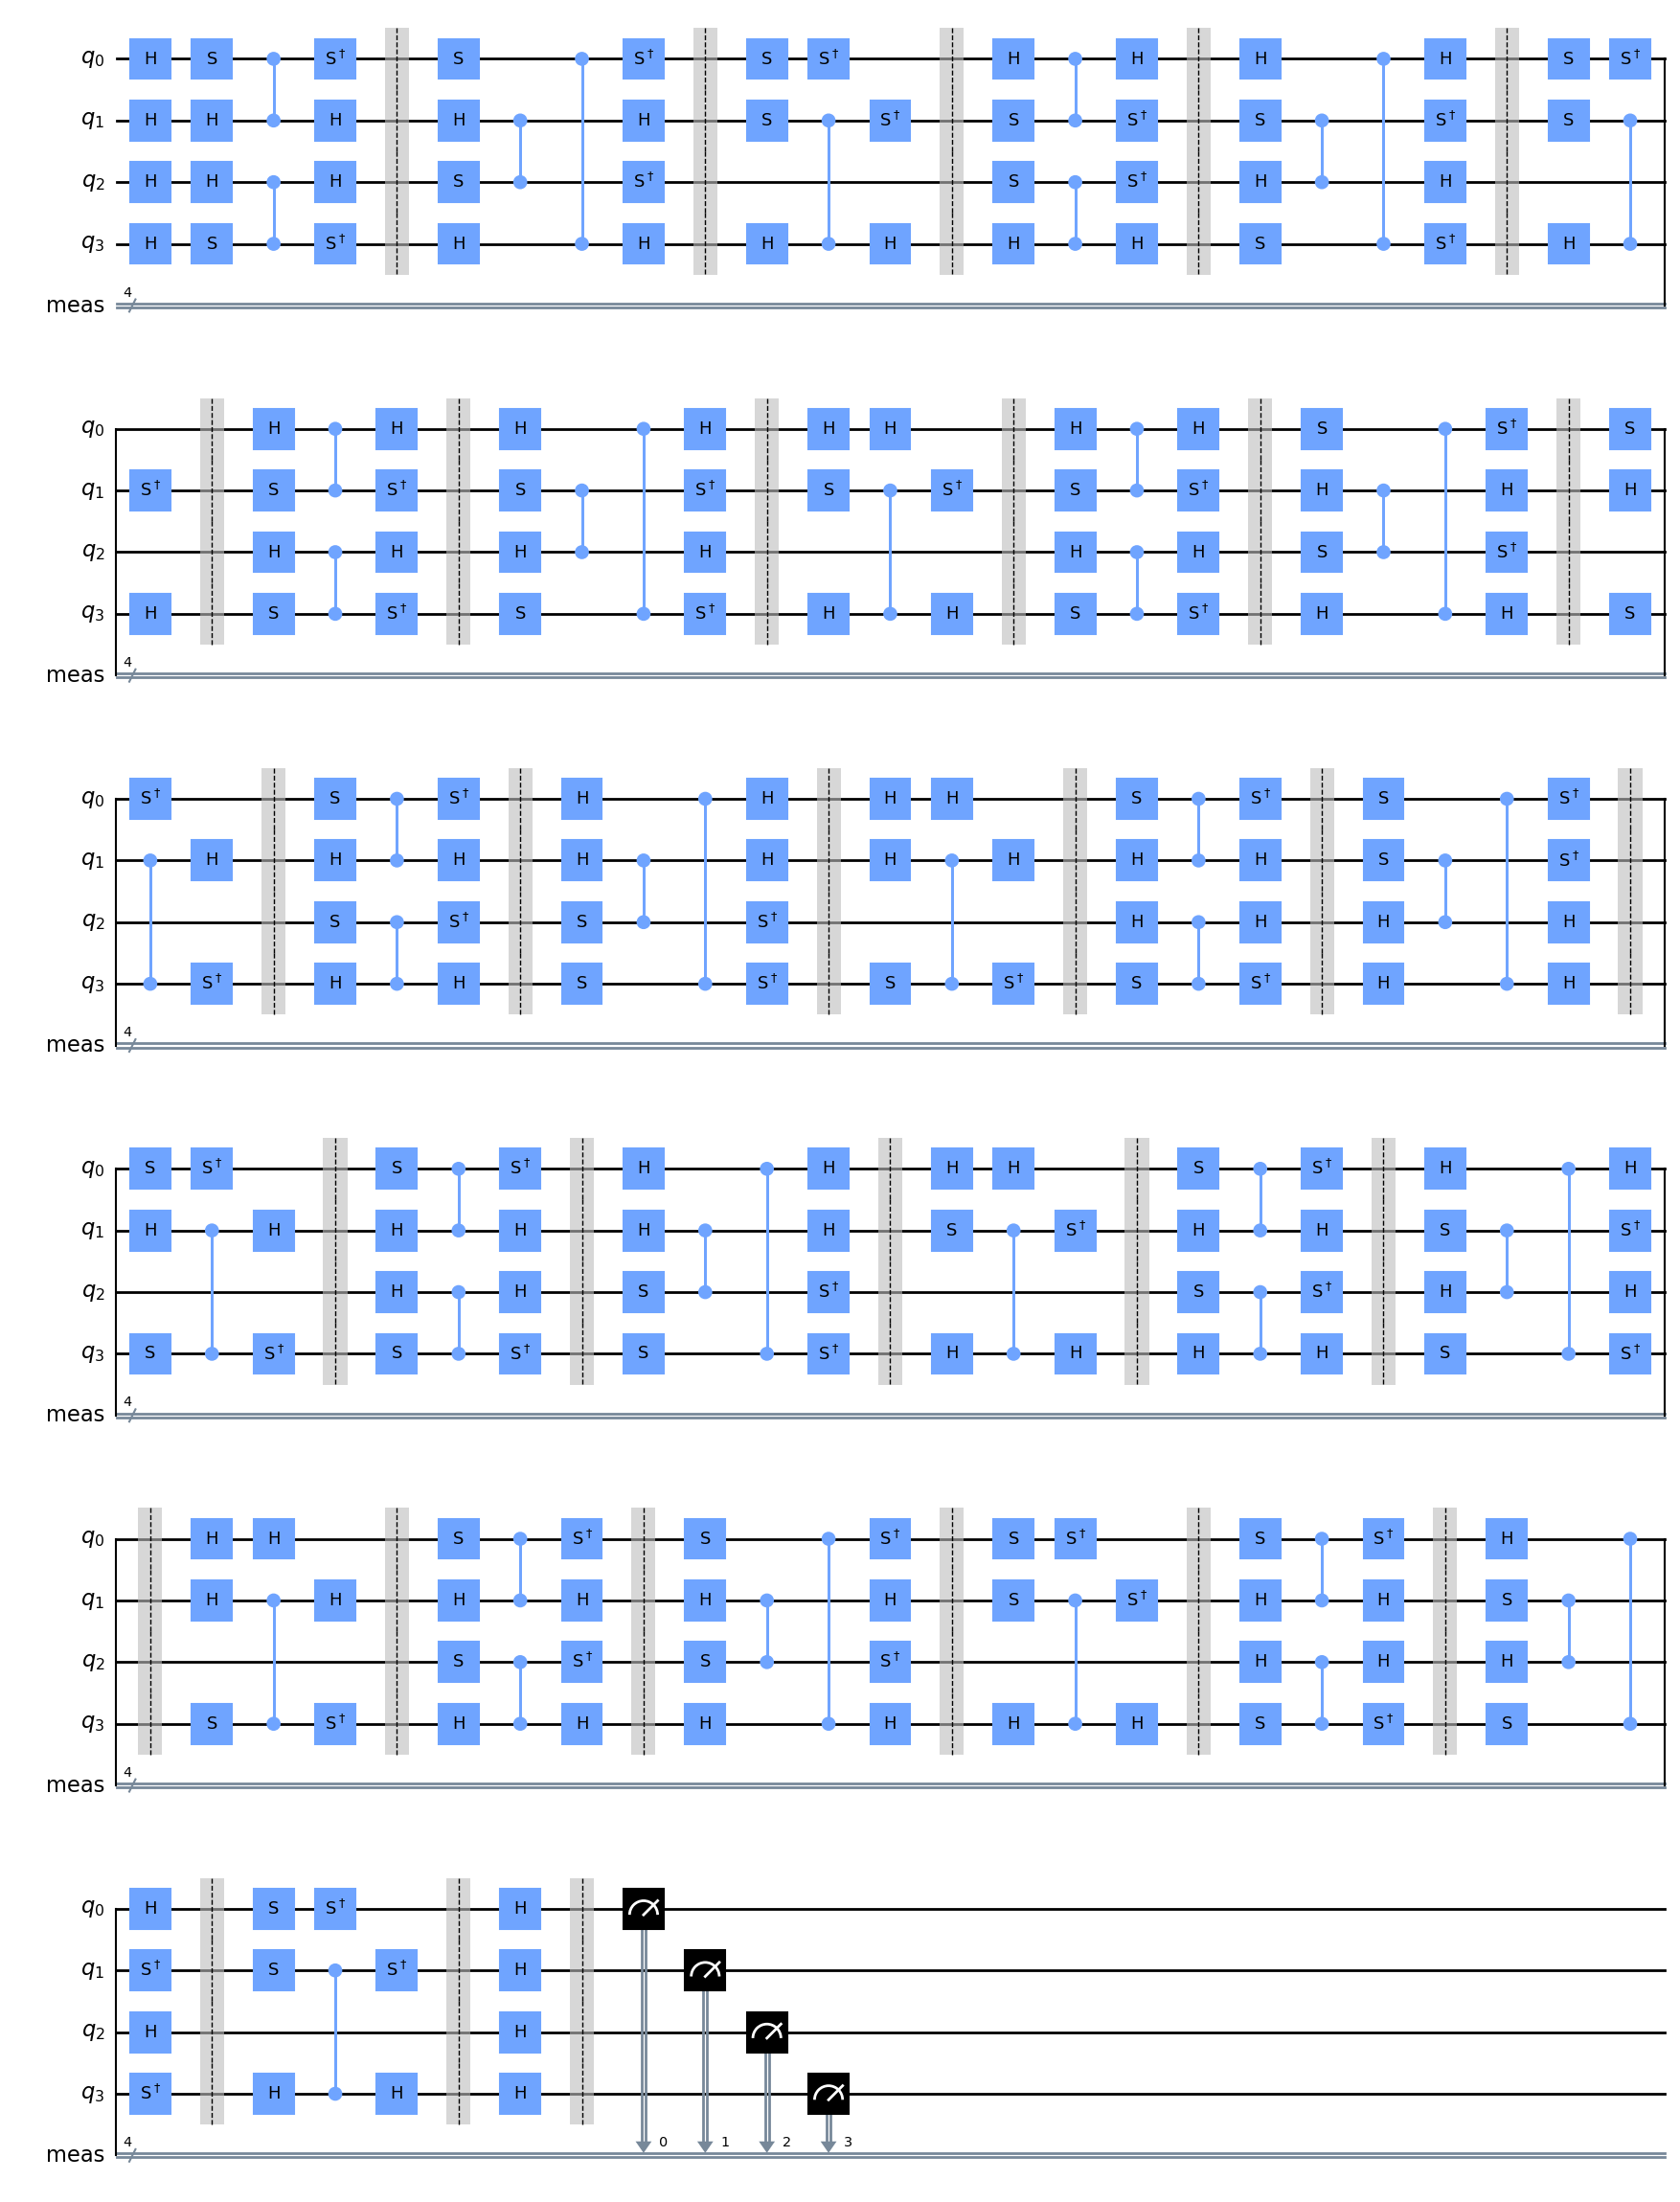

In [30]:
trap_circuits = generate_trap_circuits(v, tc)
# Draw an example
trap_circuits[0].draw(output='mpl')

## Noiseless simulation

We can expect perfect results from noiseless simulation.

In [31]:
sim = AerSimulator()
failures = 0
for trap_c in trap_circuits:
    counts = sim.run(trap_c, shots=1).result().get_counts()
    if "0000" not in counts:
        failures += 1

print(f"There were {failures} failures out of {v} trap circuits. AP certifies that VD is upper-bounded by  {2 * failures / v} with accuracy {mu} and confidence {eta}.")
print(f"b =  {2 * failures / v} with accuracy {mu} and confidence {eta}.")

There were 0 failures out of 57 trap circuits. AP certifies that VD is upper-bounded by  0.0 with accuracy 0.0001 and confidence 0.9999.
b =  0.0 with accuracy 0.0001 and confidence 0.9999.


## Noisy simulation

In [8]:
import sys
import pathlib
import os
sys.path.insert(0, str(pathlib.Path(os.path.abspath('')).parent.parent.parent.resolve()))
from _helpers.circuit_submitter import CircuitSubmitter

device_name = "noisy_sim_with_shots"
submitter = CircuitSubmitter("accreditation", device_name)

# Uncomment the following lines if you are using a noisy simulator and would like to change the noise model
# noise_model = None
# submitter.backend.device.set_noise_model(noise_model=noise_model)

In [32]:
submitter.submit_circuits(shots=1, qasm_strs=[t.qasm() for t in trap_circuits], skip_asking=True)
all_counts = submitter.retrieve_counts()
failures = 0
for counts in all_counts:
    if "0000" not in counts:
        failures += 1

print(f"There were {failures} failures out of {v} trap circuits. AP certifies that VD is upper-bounded by {2 * failures / v} with accuracy {mu} and confidence {eta}.")
print(f"b =  {2 * failures / v} with accuracy {mu} and confidence {eta}.")

Ready to run 57 circuits on noisy_sim_with_shots with 1 shots.
Cost: 57 * ($0 + 1 * $0) = $0.00.
Circuits have been submitted
2024-10-18 11:13:57 All circuits are finished
There were 22 failures out of 57 trap circuits. AP certifies that VD is upper-bounded by 0.7719298245614035 with accuracy 0.0001 and confidence 0.9999.
b =  0.7719298245614035 with accuracy 0.0001 and confidence 0.9999.
